In [1]:
import numpy as np
import networkx as nx

import matplotlib.pyplot as plt

from src.resource_estimates.hubbard_model_simple import hubbard_model_phase_estimation_resources, hubbard_model_time_evolution_resources


# Simulation of anistropic graphene:

In this notebook we consider the quantum simulation of anisotropic graphene. First we construct a function the computes the hopping graph and decomposes the graph into s1 tiles associated with the different weights.

In the next two sections we compute the T-gate requirements to simulate time evolution and to run Quantum Phase estimation.

In [2]:
def color_anisotropic_graphene(Lx: int, Ly: int, t1: float, t2: float, t3: float) -> tuple[nx.Graph, ...]:
    whole = nx.hexagonal_lattice_graph(m=Ly, n=2*Lx, periodic=True, with_positions=True)

    lx, ly = 2*Lx, 2*Ly

    Gr, Gb, Gy = nx.Graph(), nx.Graph(), nx.Graph()
    for g in [Gr, Gb, Gy]:
        g.add_nodes_from(whole.nodes)

    for i in range(ly):
        for j in range(Lx):
            x = 2 * j + (i % 2)
            y = i
            Gr.add_edge(
                    (x,y),((x+1) % lx, y % ly), weight = t1
            )
            whole[(x,y)][((x+1) % lx, y % ly)]["weight"] = t1

            Gb.add_edge(
                    (x,y),(x % lx, (y+1) % ly), weight = t2
            )
            whole[(x,y)][(x % lx, (y+1) % ly)]["weight"] = t2

            Gy.add_edge(
                    (x,y),(x % lx, (y-1) % ly), weight = t3
            )
            whole[(x,y)][(x % lx, (y-1) % ly)]["weight"] = t3

    return Gr, Gb, Gy, whole


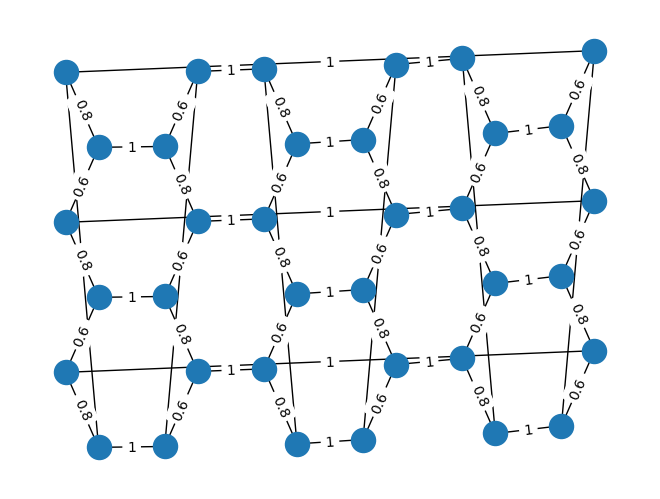

In [3]:
Gr, Gb, Gy, G = color_anisotropic_graphene(3,3, 1, 0.8, 0.6)
pos = nx.get_node_attributes(G, 'pos')
edge_labels = nx.get_edge_attributes(G, "weight")
nx.draw(G, pos, with_labels = 0)
_ = nx.draw_networkx_edge_labels(G, pos, edge_labels)

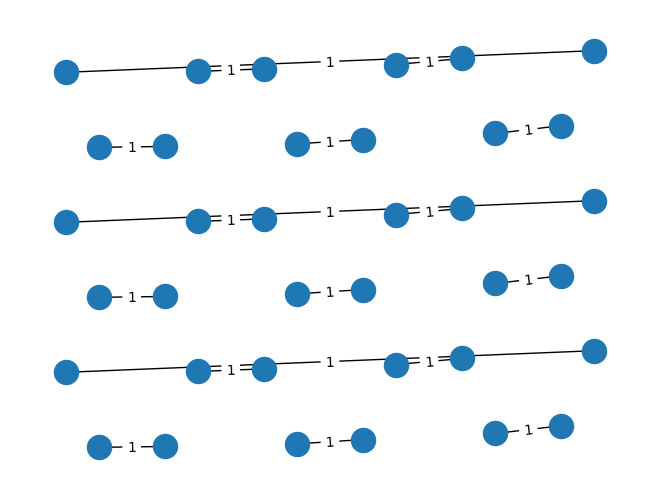

In [4]:
nx.draw(Gr, pos, with_labels = 0)
edge_labels = nx.get_edge_attributes(Gr, "weight")
_ = nx.draw_networkx_edge_labels(Gr, pos, edge_labels)

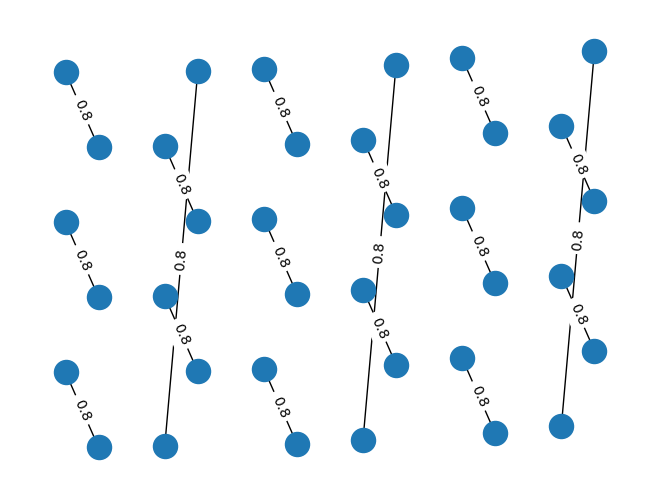

In [5]:
nx.draw(Gb, pos, with_labels = 0)
edge_labels = nx.get_edge_attributes(Gb, "weight")
_ = nx.draw_networkx_edge_labels(Gb, pos, edge_labels)

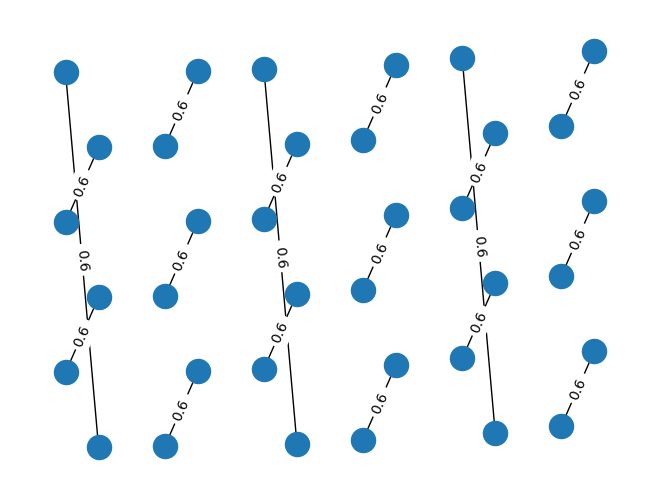

In [6]:
nx.draw(Gy, pos, with_labels = 0)
edge_labels = nx.get_edge_attributes(Gy, "weight")
_ = nx.draw_networkx_edge_labels(Gy, pos, edge_labels)

In [7]:
def dict_to_t_count(dct: dict) -> int:
    tc = 0
    if "t" in dct.keys():
        tc += dct["t"] 
        
    if "tdg" in dct.keys():
        tc += dct["tdg"] 
        
    if "toffoli" in dct.keys():
        tc += 4*dct["toffoli"]
    return tc

U = 4
tau = 1
x = 0.01

# Hamiltonian evolution:

/home/aftkvantify/lie-algebra-trotterization/src/resource_estimates/rotation_synthesis.py:43: UserWarning: When synthesizing rotation into clifford plus T, this function does not compute the single-qubit clifford count due to arbitrary rotations.
  warnings.warn(


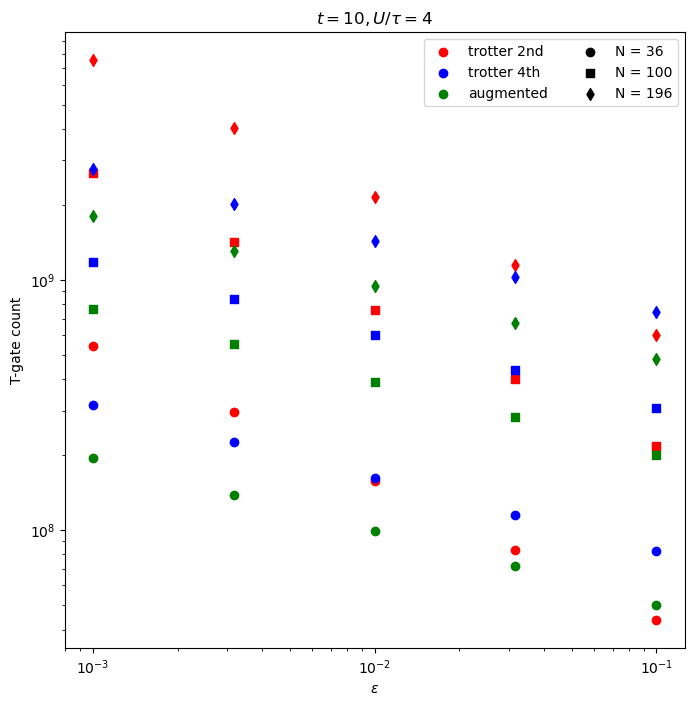

In [8]:
t = 10
logeps_list = np.linspace(-3, -1, 5)
eps_list = np.pow(10, logeps_list)
Ls = [3, 5, 7]

colors = ['r', 'b', 'g']
marker_styles = ['o', 's', 'd']
comp_strats = ["trotter 2nd", "trotter 4th", "augmented"]
comp_args = ["trotter", "trotter_4th", "augmented"]

fig, ax = plt.subplots(figsize = (8, 8))

for strat, color in zip(comp_strats, colors):
    ax.scatter([],[], c = color, marker = "o", label = strat)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(rf"$\varepsilon$")
ax.set_ylabel(f"T-gate count")
ax.set_title(rf"$t = {t}, U / \tau = {U}$")

Ns = []
for comp, color, comp_strat in zip(comp_args, colors, comp_strats):
    for L, marker_style in zip(Ls, marker_styles):
        G1, G2, G3, G = color_anisotropic_graphene(L, L, 1, 0.8, 0.6)
        Ns.append(len(G.nodes))
        decomp = [G1,G2,G3]
        dcts = [hubbard_model_time_evolution_resources(
            U,
            tau, 
            G,
            t,
            e,
            comp,
            decomp,
            x=x,
            hwp = 0
        )
            for e in eps_list
        ]
        ys_t = [dict_to_t_count(d) for d in dcts]
        ax.scatter(eps_list, ys_t, marker = marker_style, c = color)
        
for N, marker in zip(Ns, marker_styles):
    ax.scatter([],[], c = "k", marker = marker, label = f"N = {N}")
ax.legend(ncol = 2)

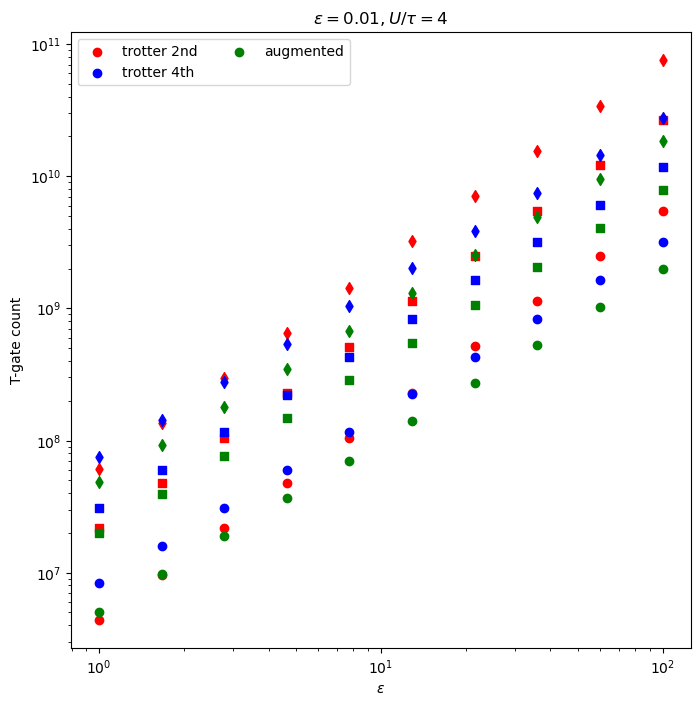

In [9]:
logts = np.linspace(0, 2, 10)
ts = np.pow(10, logts)
eps = 0.01
Ls = [3, 5, 7]

colors = ['r', 'b', 'g']
marker_styles = ['o', 's', 'd']
comp_strats = ["trotter 2nd", "trotter 4th", "augmented"]
comp_args = ["trotter", "trotter_4th", "augmented"]

fig, ax = plt.subplots(figsize = (8, 8))

for strat, color in zip(comp_strats, colors):
    ax.scatter([],[], c = color, marker = "o", label = strat)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(rf"$\varepsilon$")
ax.set_ylabel(f"T-gate count")
ax.set_title(rf"$\varepsilon = {eps}, U / \tau = {U}$")

Ns = []
for comp, color, comp_strat in zip(comp_args, colors, comp_strats):
    for L, marker_style in zip(Ls, marker_styles):
        G1, G2, G3, G = color_anisotropic_graphene(L, L, 1, 0.8, 0.6)
        decomp = [G1,G2,G3]
        dcts = [hubbard_model_time_evolution_resources(
            U,
            tau, 
            G,
            t,
            eps,
            comp,
            decomp,
            x=x,
            hwp = 0
        )
            for t in ts
        ]
        ys_t = [dict_to_t_count(d) for d in dcts]
        ax.scatter(ts, ys_t, marker = marker_style, c = color)
        
for N, marker in zip(Ns, marker_styles):
    ax.scatter([],[], c = "k", marker = marker, label = f"N = {N}")
ax.legend(ncol = 2)

# Quantum Phase estimation:

/home/aftkvantify/lie-algebra-trotterization/src/resource_estimates/quantum_phase_estimation.py:144: UserWarning: minimize failed to converge with msg:
ABNORMAL: 
  warnings.warn(


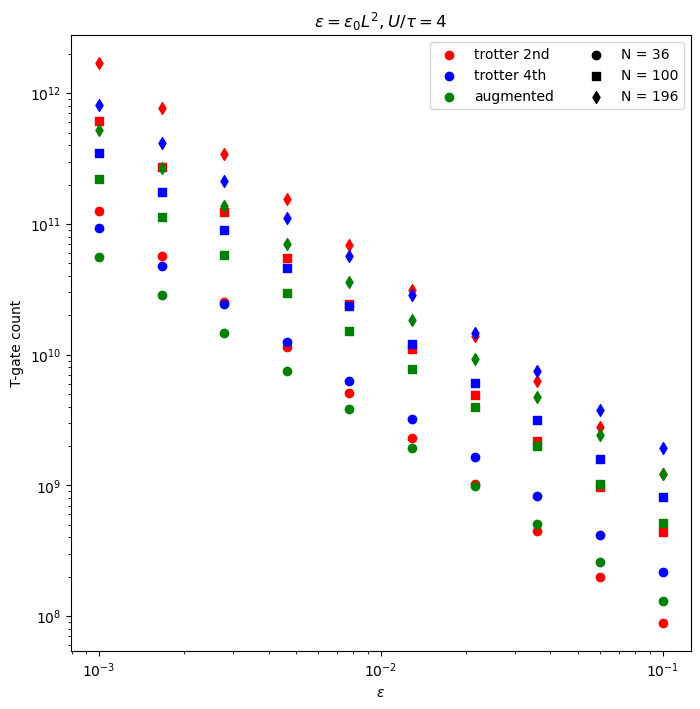

In [10]:
logeps_list = np.linspace(-3, -1, 10)
eps_list = np.pow(10, logeps_list)
Ls = [3, 5, 7]

colors = ['r', 'b', 'g']
marker_styles = ['o', 's', 'd']
comp_strats = ["trotter 2nd", "trotter 4th", "augmented"]
comp_args = ["trotter", "trotter_4th", "augmented"]

fig, ax = plt.subplots(1, figsize = (8, 8))

for strat, color in zip(comp_strats, colors):
    ax.scatter([],[], c = color, marker = "o", label = strat)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(rf"$\varepsilon$")
ax.set_ylabel(f"T-gate count")
ax.set_title(rf"$\varepsilon = \varepsilon_0 L^2, U / \tau = {U}$")

Ns = []
for comp, color, comp_strat in zip(comp_args, colors, comp_strats):
    for L, marker_style in zip(Ls, marker_styles):
        G1, G2, G3, G = color_anisotropic_graphene(L, L, 1, 0.8, 0.6)
        Ns.append(len(G.nodes))
        decomp = [G1,G2,G3]
        dcts = [hubbard_model_phase_estimation_resources(
            U,
            tau,
            G,
            e,
            time_evolution_algorithm=comp,
            decomp = decomp,
            x = x,
            hwp = 0
        )
            for e in eps_list
               ]
        ys = [dict_to_t_count(d) for d in dcts]
        ax.scatter(eps_list, ys, marker = marker_style, c = color)
        
for L, marker in zip(Ns, marker_styles):
    ax.scatter([],[], c = "k", marker = marker, label = f"N = {L}")
ax.legend(ncol = 2)

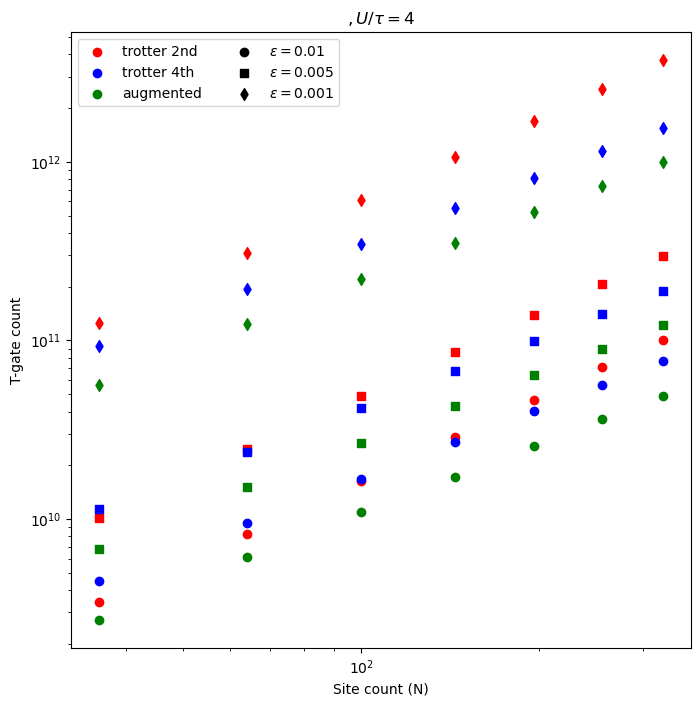

In [11]:
Ls = [3, 4, 5, 6, 7, 8,9]
epss = [0.01, 0.005, 0.001]

colors = ['r', 'b', 'g']
marker_styles = ['o', 's', 'd']
comp_strats = ["trotter 2nd", "trotter 4th", "augmented"]
comp_args = ["trotter", "trotter_4th", "augmented"]

fig, ax = plt.subplots(1, figsize = (8, 8))

for strat, color in zip(comp_strats, colors):
    ax.scatter([],[], c = color, marker = "o", label = strat)

for e, marker in zip(epss, marker_styles):
    ax.scatter([],[], c = "k", marker = marker, label = rf"$\varepsilon = {e}$")
    
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(rf"Site count (N)")
ax.set_ylabel(f"T-gate count")
ax.legend(ncol = 2)
ax.set_title(rf"$, U / \tau = {U}$")

Ns = [len(color_anisotropic_graphene(L,L,1,0.8,0.6)[-1].nodes) for L in Ls]
for comp, color, comp_strat in zip(comp_args, colors, comp_strats):
    for e, marker_style in zip(epss, marker_styles):
        dcts = []
        for L in Ls:
            G1, G2, G3, G = color_anisotropic_graphene(L, L, 1, 0.8, 0.6)
            decomp = [G1,G2,G3]
            dcts.append(hubbard_model_phase_estimation_resources(
                U,
                tau,
                G,
                e,
                time_evolution_algorithm=comp,
                decomp = decomp,
                x = x,
                hwp = 0
            ))
        ys = [dict_to_t_count(d) for d in dcts]
        ax.scatter(Ns, ys, marker = marker_style, c = color)
        